# WMT-Human — Analysis

Models:
- Mistral
- LLaMA
- GPT-4o

In [21]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [23]:
# Load preprocessed data (run preprocessing.ipynb first if needed)
df = pd.read_csv('../data/wmt-human_en_de_judged_cleaned.csv')

print(f"Loaded cleaned dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Loaded cleaned dataset shape: (9779, 6)
Columns: ['human_#1', 'human_#2', 'human_#3', 'GPT-4o_as_a_judge', 'Mistral_as_a_judge', 'Llama_as_a_judge']


,human_#1,human_#2,human_#3,GPT-4o_as_a_judge,Mistral_as_a_judge,Llama_as_a_judge
0,4,2,4,6.0,6.0,4.0
1,4,5,4,6.0,6.0,4.0
2,5,5,4,6.0,6.0,4.0
3,4,4,4,6.0,6.0,4.0
4,4,0,4,6.0,6.0,4.0


In [24]:
# Define column names and score range for analysis
human_cols = [col for col in df.columns if col.startswith('human_')]
llm_cols = [col for col in df.columns if col.endswith('as_a_judge')]
MIN, MAX = 0, 6

print(f"Human columns: {human_cols}")
print(f"LLM columns: {llm_cols}")
print(f"Score range: [{MIN}, {MAX}]")

Human columns: ['human_#1', 'human_#2', 'human_#3']
LLM columns: ['GPT-4o_as_a_judge', 'Mistral_as_a_judge', 'Llama_as_a_judge']
Score range: [0, 6]


## Diversity of opinion

- initialize evaluator instance:

📊 Computing disagreement distributions...


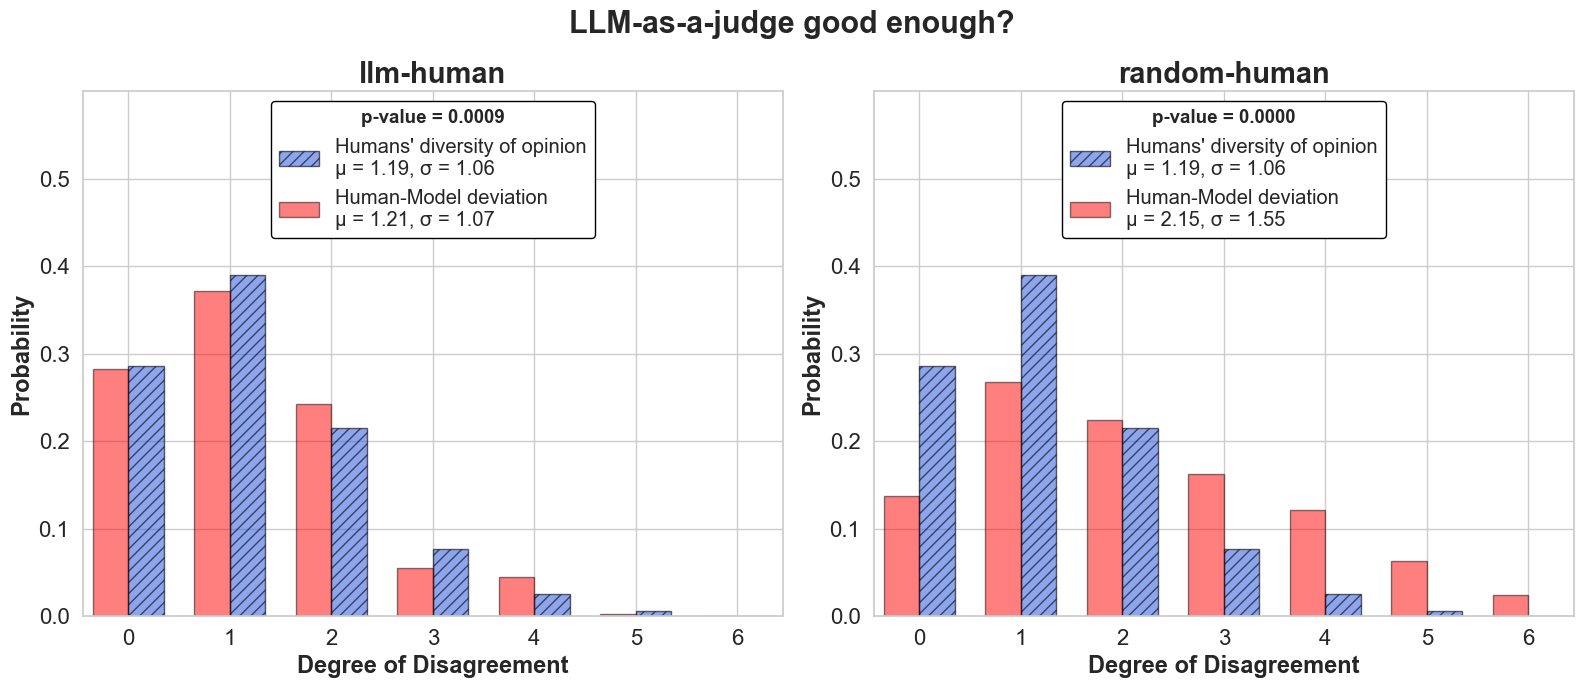

In [ ]:
# Fix import path - add parent directory to Python path
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..', '..', '..'))

from core.llm_good_enough import LLMGoodEnough

SEED = 42

good_enough = LLMGoodEnough(
    df=df,
    human_cols=human_cols,
    llm_cols=llm_cols,
    min_score=MIN,
    max_score=MAX,
    seed=SEED,
    verbosity=0
)

# visualize LLM-as-a-judge good enough
good_enough.visualize_good_enough(llm_col='Llama_as_a_judge', y_lim=0.6)

### 1. Human-Human disagreement

In [26]:
human_human_disagreements = good_enough.compute_human_disagreements()

print(human_human_disagreements.shape)
# mean and std (=2 decimal places)
print(f"Mean: {round(human_human_disagreements.mean(), 2)}")
print(f"Std: {round(human_human_disagreements.std(), 2)}")

(29337,)
Mean: 1.19
Std: 1.06


### 2. LLM-Human disagreement

In [27]:
# print shapes, mean and std (=2 decimal places)
print(f"LLAMA:")
llama_human_disagreements = good_enough.compute_llm_human_disagreements('Llama_as_a_judge')
print(f"   - Shape: {llama_human_disagreements.shape}")
print(f"   - Mean: {round(llama_human_disagreements.mean(), 3)}")
print(f"   - Std: {round(llama_human_disagreements.std(), 3)}")
print()

print(f"MISTRAL:")
mistral_human_disagreements =  good_enough.compute_llm_human_disagreements('Mistral_as_a_judge')
print(f"   - Shape: {mistral_human_disagreements.shape}")
print(f"   - Mean: {round(mistral_human_disagreements.mean(), 3)}")
print(f"   - Std: {round(mistral_human_disagreements.std(), 3)}")
print()

print(f"GPT-4o:")
gpt4o_human_disagreements = good_enough.compute_llm_human_disagreements('GPT-4o_as_a_judge')
print(f"   - Shape: {gpt4o_human_disagreements.shape}")
print(f"   - Mean: {round(gpt4o_human_disagreements.mean(), 3)}")
print(f"   - Std: {round(gpt4o_human_disagreements.std(), 3)}")

LLAMA:
   - Shape: (27906,)
   - Mean: 1.214
   - Std: 1.067

MISTRAL:
   - Shape: (28383,)
   - Mean: 1.808
   - Std: 1.414

GPT-4o:
   - Shape: (26427,)
   - Mean: 1.564
   - Std: 1.24


### 3. Random-Human disagreement


**Note:** computed internally during instance initialization.

In [28]:
import random

# set seed for reproducibility
random.seed(42)

MIN, MAX = 0, 6

# compute random judge
df['RANDOM_as_a_judge'] = np.random.randint(MIN, MAX + 1, size=len(df))

# compute human-random judge disagreement
human_random_disagreements = good_enough.compute_llm_human_disagreements('RANDOM_as_a_judge')

# print shapes, mean and std (=2 decimal places)
print(f"RANDOM:")
print(f"   - Shape: {human_random_disagreements.shape}")
print(f"   - Mean: {round(human_random_disagreements.mean(), 3)}")
print(f"   - Std: {round(human_random_disagreements.std(), 3)}")

RANDOM:
   - Shape: (29337,)
   - Mean: 2.15
   - Std: 1.549


## Results

**Hypotheses (MWU, one-sided `alternative="greater"`):**
- **H₀:** LLM–Human disagreement is not greater than Human–Human disagreement.
- **H₁:** LLM–Human disagreement is greater.

In [29]:
from scipy.stats import mannwhitneyu

# compute mann-whitney u test and round to 4 decimal places
llama_human_pvalue = mannwhitneyu(
    llama_human_disagreements, human_human_disagreements, alternative='greater'
).pvalue
print(f"LLAMA vs. Human: {round(llama_human_pvalue, 4)}")

gpt4o_human_pvalue = mannwhitneyu(
    gpt4o_human_disagreements, human_human_disagreements, alternative='greater'
).pvalue

print(f"GPT-4o vs. Human: {round(gpt4o_human_pvalue, 4)}")

mistral_human_pvalue = mannwhitneyu(
    mistral_human_disagreements, human_human_disagreements, alternative='greater'
).pvalue

print(f"MISTRAL vs. Human: {round(mistral_human_pvalue, 4)}")

random_human_pvalue = mannwhitneyu(
    human_random_disagreements, human_human_disagreements, alternative='greater'
).pvalue

print(f"RANDOM vs. Human: {round(random_human_pvalue, 4)}")

LLAMA vs. Human: 0.0009
GPT-4o vs. Human: 0.0
MISTRAL vs. Human: 0.0
RANDOM vs. Human: 0.0


✅ Figure saved as PDF → ../figures/pdf/wmt_barplot.pdf


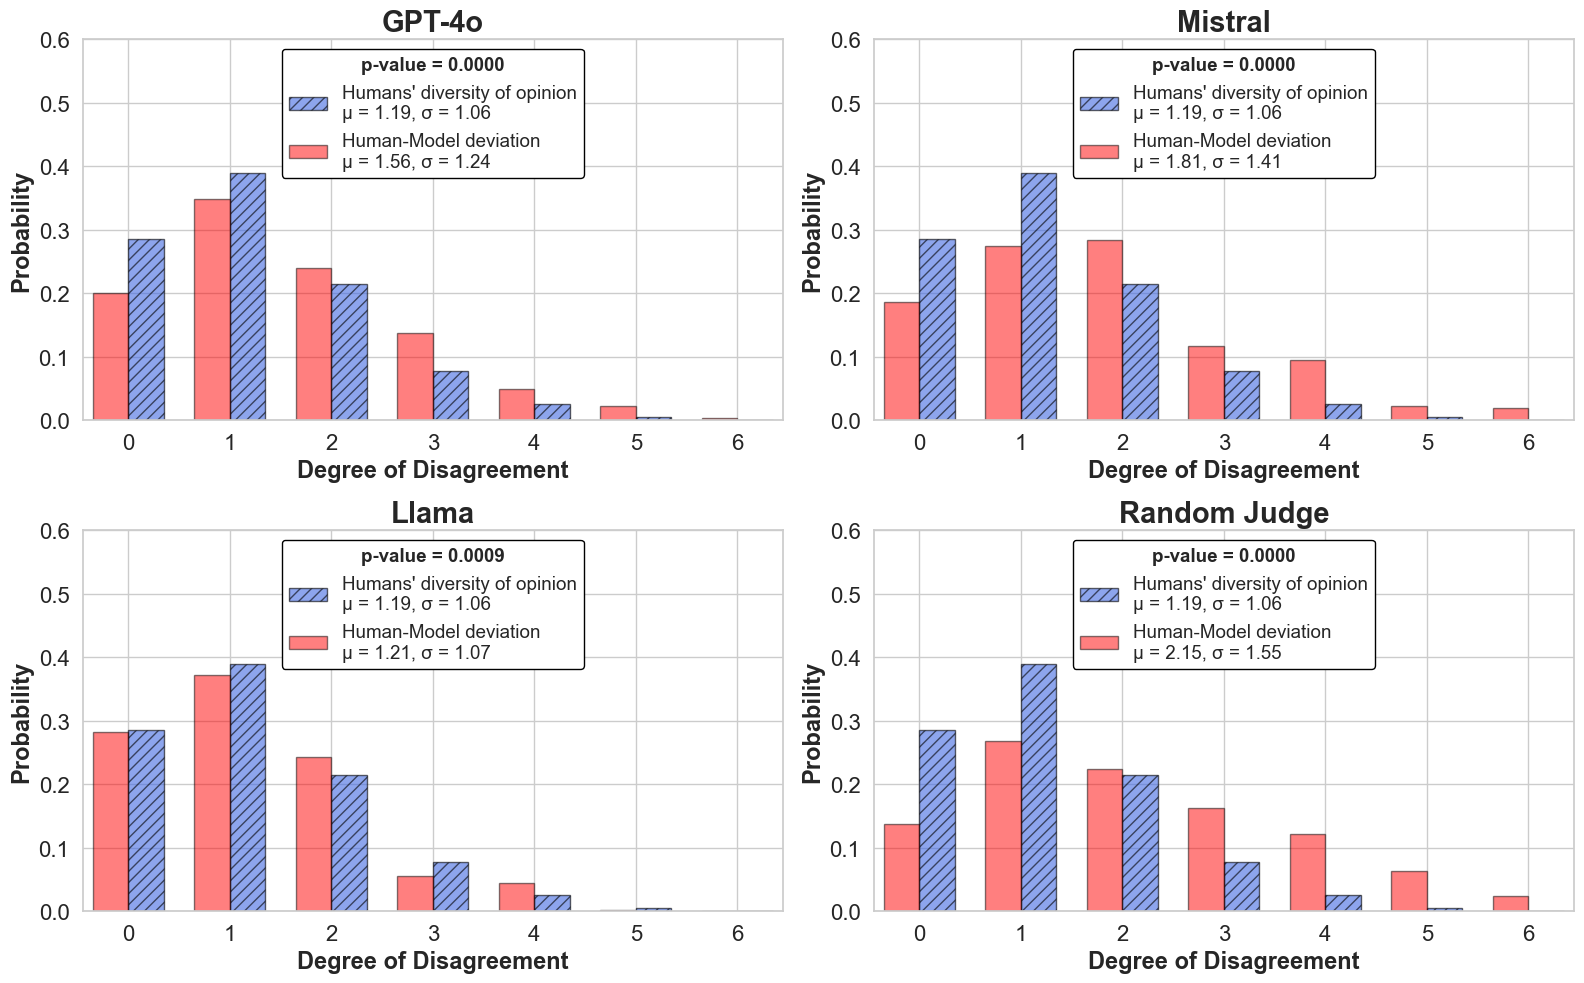

In [30]:
good_enough.plot_judges_grid(
    bins=np.arange(0, 8),
    bar_width=0.35,
    y_lim=0.6,
    save_path="../figures/pdf/wmt_barplot.pdf"
)

## Robustness (Monte Carlo)

→ Running robustness analysis for all models ...


/Users/sebastianwefers/Desktop/projects/LLM_as_a_Judge_good_enough/benchmarks/wmt-human/src/../../../core/llm_good_enough/evaluator.py:818: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(pA, fill=True, ax=axes[0], label=label_pA, alpha=0.5, color="royalblue")
/Users/sebastianwefers/Desktop/projects/LLM_as_a_Judge_good_enough/benchmarks/wmt-human/src/../../../core/llm_good_enough/evaluator.py:819: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(pB, fill=True, ax=axes[0], label=label_pB, alpha=0.5, color="#333333")
/Users/sebastianwefers/Desktop/projects/LLM_as_a_Judge_good_enough/benchmarks/wmt-human/src/../../../core/llm_good_enough/evaluator.py:829: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes

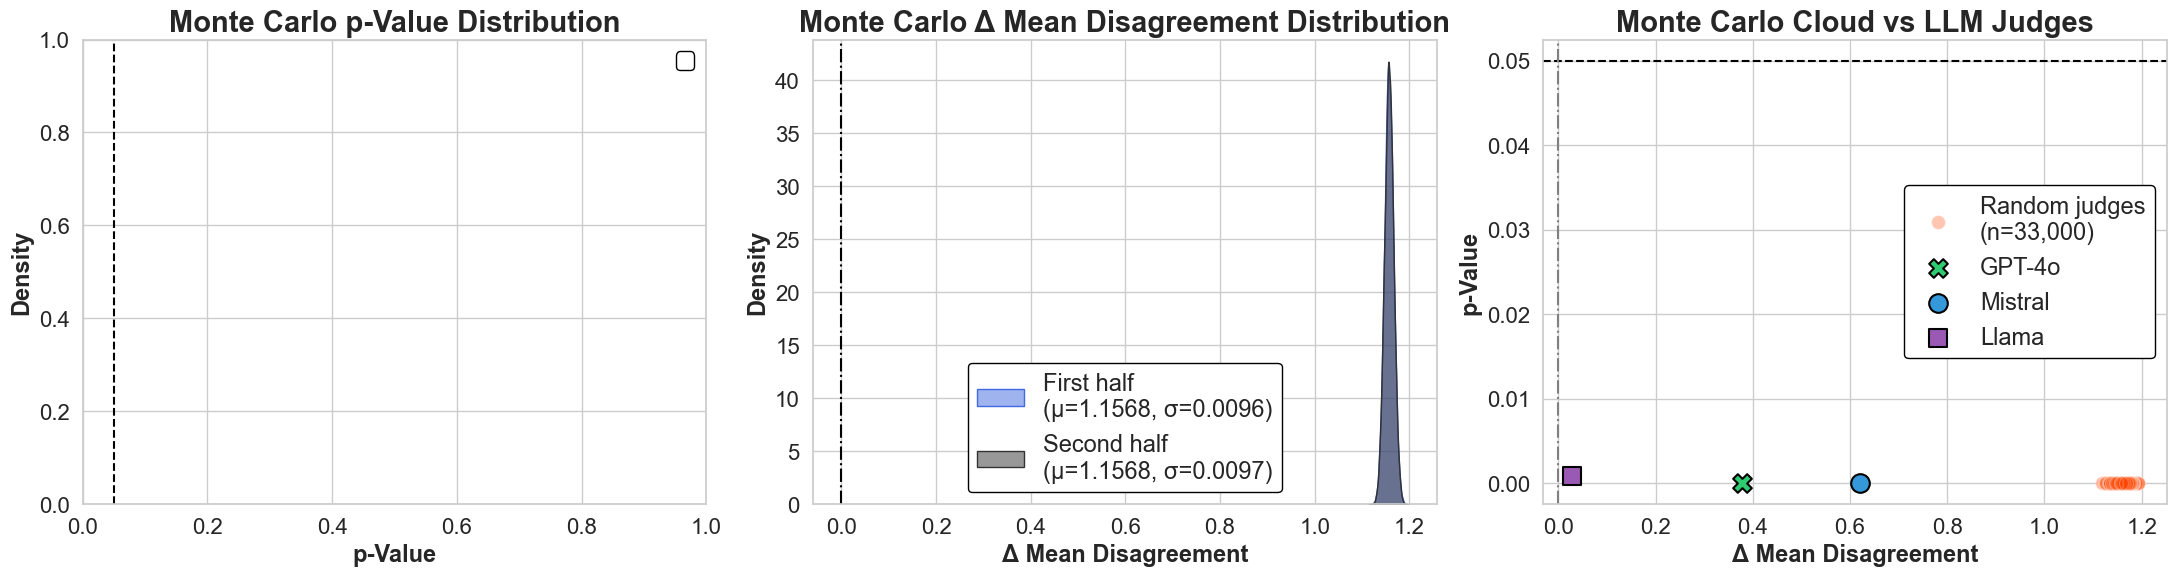

In [32]:
# --- Robustness visualization for all models in one figure ---

print("→ Running robustness analysis for all models ...")
good_enough.plot_monte_carlo_robustness_multi(
    llm_cols=llm_cols,
    iterations=33_000,
    save_path="../figures/pdf/wmt_monte_carlo_robustness.pdf"
)

## Human Stability Analysis

In [ ]:
good_enough.plot_human_stability_analysis(
    convergence_threshold=0.000005,
    min_iterations=20_000,
    max_iterations=500_000,
    parallel=True,
    save_path="../figures/pdf/wmt_human_stability.pdf"
)

In [ ]:
good_enough.plot_human_stability_analysis(
    percentages=[10, 20, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500],
    convergence_threshold=0.00001,
    min_iterations=1_000,
    max_iterations=100_000,
    save_path="../figures/pdf/wmt_human_stability_100plus.pdf"
)

### LLM Stability Analysis

In [ ]:
models = ['GPT', 'LLAMA', 'MISTRAL']

for model in models:
    print(f"Model: {model}")
    good_enough.plot_llm_stability_analysis(
        llm_col=f"{model}_as_a_judge",
        convergence_threshold=0.000005,
        min_iterations=20_000,
        max_iterations=500_000,
        save_path=f"../figures/pdf/wmt_{model}_stability_analysis.pdf",
        parallel=True,
    )
    print("-"*99)

Model: GPT


KeyboardInterrupt: 